# Task 2 — Customer Segmentation bằng K-Means
**Người phụ trách: Nguyễn Tuấn Duy — Nhóm 11**

Mục tiêu: tìm nhóm khách hàng tương đồng trong dữ liệu mô phỏng, chọn K bằng Elbow và Silhouette, so sánh PCA/non-PCA, gắn nhãn về dữ liệu giao dịch và xuất bộ mô hình dùng lại.

**Cách chạy:** giải nén gói vào thư mục riêng hoặc chép đúng cấu trúc vào dự án. Cài `pip install -r requirements-task2.txt`, mở notebook và **Restart Kernel → Run All**. Các hàm dùng chung được đặt trong `src/segmentation/customer_kmeans.py`; notebook thực hiện đầy đủ từng bước bên dưới.

**Phạm vi:** phân nhóm khách hàng, không phải phân lớp Rating. Fit trên toàn bộ snapshot để mô tả dữ liệu; các chỉ số là đánh giá nội bộ, không phải độ chính xác trên khách hàng tương lai. Không sửa `cleaned_dataset.csv` hay các task khác.

**Output:** đúng 2 CSV trong `data/final/`; hình trong `notebooks/figures/kmeans/`; model trong `src/models/`. Bảng đánh giá và nhận xét hiển thị ngay trong notebook. Task 2 không ghi file vào `report/`. Gói cập nhật dùng với dữ liệu đầu vào hiện có của dự án.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
from IPython.display import display, Image, Markdown

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'data/final/cleaned_dataset.csv').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Không thấy data/final/cleaned_dataset.csv. Hãy giải nén đầy đủ gói bài tập.')
sys.path.insert(0, str(ROOT))
from src.segmentation.customer_kmeans import (
    NUMERIC, load_and_audit, build_customers, prepare_spaces, evaluate_k,
    choose_models, demographic_sensitivity, make_profiles, save_figures,
    export_results, predict_customers)
print('Project:', ROOT)


# Chỉ định dạng bản sao để hiển thị, không thay đổi dữ liệu tính toán.
def hien_thi(obj):
    if isinstance(obj, pd.DataFrame):
        view = obj.copy()
        def format_value(value):
            if isinstance(value, (int, np.integer)):
                return f"{value:,}"
            if isinstance(value, (float, np.floating)):
                return "—" if pd.isna(value) else f"{value:,.3f}"
            return value
        for column in view.columns:
            view[column] = view[column].map(format_value)
        display(view)
    else:
        display(obj)


Project: /workspace/scratch/fde0fa8f8810/task2_project


## 1. Đọc và kiểm tra dữ liệu
Kiểm tra khóa giao dịch, cột cốt lõi, ngày, miền giá trị và tính nhất quán của khách hàng. Không dùng `dropna()` toàn bảng: thiếu do nguồn ở metadata không có nghĩa giao dịch không hợp lệ.

Notebook Cleaning hiện khởi tạo lại `df_cleaned = df.copy()` trong bước outlier, làm mất các lần điền trước đó. Task này kiểm tra trực tiếp dữ liệu đã xuất và chỉ chọn cột phù hợp. `Revenue` có giá trị đã clip nên không tự tính lại từ đơn giá × số lượng.

In [2]:
df, audit = load_and_audit(ROOT / 'data/final/cleaned_dataset.csv')
print('Dòng/cột:', df.shape, '| Khách hàng:', audit['customers'])
print('Revenue khác Quantity × Unit_Price_VND:', audit['revenue_formula_mismatch'])
hien_thi(pd.Series(audit['missing_by_column'], name='Missing').to_frame())
hien_thi(df[['Customer_ID','Transaction_Date','Revenue','Quantity','Discount_Ratio']].head())

,Missing
avg_rating,"8,178"
reviews_count,"8,178"
rating_average,"1,822"
review_count,"1,822"
quantity_sold,"1,822"
availability,"8,178"
is_for_sale,"8,178"
product_type,"8,178"
category_2,"8,178"
category_3,"8,178"


,Customer_ID,Transaction_Date,Revenue,Quantity,Discount_Ratio
0,C01049,2026-05-27 07:53:23,"111,000.000",3.000,0.000
1,C00099,2025-11-03 05:40:50,"71,250.000",3.000,0.050
2,C00503,2025-09-30 17:07:01,"1,010,000.000",1.000,0.000
3,C00810,2026-07-05 23:45:05,"1,170,000.000",2.000,0.000
4,C00241,2026-01-05 19:27:32,"1,041,696.000",3.000,0.000


Dòng/cột: (10000, 42) | Khách hàng: 1988
Revenue khác Quantity × Unit_Price_VND: 10


## 2. Tạo bảng khách hàng và chọn đặc trưng
Một dòng = một `Customer_ID`. Mốc tham chiếu cố định là ngày sau ngày giao dịch cuối trong snapshot (không dùng ngày chạy máy).

| Feature | Cách tính | Ý nghĩa |
|---|---|---|
| Recency | Số ngày từ lần mua cuối đến mốc tham chiếu | Giá trị nhỏ: mua gần đây |
| Frequency | Đếm Transaction_ID khác nhau | Tần suất trong cửa sổ quan sát |
| Monetary | Tổng Revenue sau làm sạch | Mức chi tiêu trong snapshot |
| Mean_Discount_Ratio | Trung bình Discount_Ratio | Mức giảm giá các giao dịch đã mua |

Không đưa ID hay văn bản review vào khoảng cách. Không dùng Rating để fit: giữ lại để mô tả sau phân nhóm. Tuổi/giới tính/thành phố chỉ dùng mô tả và thử nghiệm độ nhạy riêng. Không dùng đồng thời nhiều biến trùng ý nghĩa như tổng lượng mua và tần suất trong mô hình chính. Tỷ lệ giảm chỉ phản ánh giao dịch đã mua, chưa chứng minh khách nhạy cảm với khuyến mãi.

In [3]:
customers, reference_date = build_customers(df)
print('Mốc tham chiếu:', reference_date)
print('Bảng khách hàng:', customers.shape)
preview = customers[['Customer_ID'] + NUMERIC].head().copy()
preview['Recency'] = preview['Recency'].map('{:,.1f}'.format)
preview['Frequency'] = preview['Frequency'].map('{:,}'.format)
preview['Monetary'] = preview['Monetary'].map('{:,.0f}'.format)
preview['Mean_Discount_Ratio'] = preview['Mean_Discount_Ratio'].map('{:.2%}'.format)
preview = preview.rename(columns={
    'Customer_ID': 'Mã khách', 'Recency': 'Số ngày từ lần mua cuối',
    'Frequency': 'Số giao dịch', 'Monetary': 'Tổng chi tiêu (VND)',
    'Mean_Discount_Ratio': 'Giảm giá trung bình'})
hien_thi(Markdown('**5 khách hàng đầu tiên**'))
hien_thi(preview)

# Làm như ví dụ trong ảnh: phân cách hàng nghìn, làm tròn phần hiển thị.
desc = customers[NUMERIC].describe().T.copy()
desc['count'] = desc['count'].map('{:,.0f}'.format)
for column in ['mean', 'std', 'min', '25%', '50%', '75%', 'max']:
    desc[column] = desc[column].map('{:,.1f}'.format)
# Tỷ lệ giảm biểu diễn bằng % để không bị làm tròn thành 0,0.
ratio_stats = customers['Mean_Discount_Ratio'].describe()
for column in ['mean', 'std', 'min', '25%', '50%', '75%', 'max']:
    desc.loc['Mean_Discount_Ratio', column] = f"{ratio_stats[column]:.2%}"
desc = desc.rename(index={
    'Recency': 'Thời gian từ lần mua cuối (ngày)',
    'Frequency': 'Tần suất (giao dịch)',
    'Monetary': 'Tổng chi tiêu (VND)',
    'Mean_Discount_Ratio': 'Tỷ lệ giảm giá (%)'}, columns={
    'count': 'Số khách', 'mean': 'Trung bình', 'std': 'Độ lệch chuẩn',
    'min': 'Nhỏ nhất', '25%': 'Q1', '50%': 'Trung vị', '75%': 'Q3', 'max': 'Lớn nhất'})
hien_thi(Markdown('**Thống kê mô tả** — dấu phẩy tách hàng nghìn; dấu chấm là phần thập phân.'))
hien_thi(desc)

**5 khách hàng đầu tiên**

,Mã khách,Số ngày từ lần mua cuối,Số giao dịch,Tổng chi tiêu (VND),Giảm giá trung bình
0,C00001,161.5,4,"3,959,784",12.50%
1,C00002,92.6,2,"4,810,164",2.50%
2,C00003,7.2,6,"53,664,148",0.00%
3,C00004,273.4,1,"2,370,000",0.00%
4,C00005,362.5,1,"2,084,088",0.00%


**Thống kê mô tả** — dấu phẩy tách hàng nghìn; dấu chấm là phần thập phân.

,Số khách,Trung bình,Độ lệch chuẩn,Nhỏ nhất,Q1,Trung vị,Q3,Lớn nhất
Thời gian từ lần mua cuối (ngày),"1,988",71.5,65.1,0.0,22.9,53.5,99.4,362.5
Tần suất (giao dịch),"1,988",5.0,2.2,1.0,3.0,5.0,6.0,15.0
Tổng chi tiêu (VND),"1,988","10,955,010.2","13,491,036.3","1,000.0","3,029,176.0","6,489,100.0","13,337,417.5","130,861,706.1"
Tỷ lệ giảm giá (%),"1,988",4.97%,5.84%,0.00%,0.00%,3.09%,7.70%,49.52%


Mốc tham chiếu: 2026-09-21 00:00:00
Bảng khách hàng: (1988, 12)


## 3. Chuẩn hóa và PCA
Dùng `log1p` cho Recency/Frequency/Monetary rồi StandardScaler; tỷ lệ giảm dùng StandardScaler trực tiếp. Median imputer là dự phòng trong preprocessor, không che giấu lỗi dữ liệu đầu vào: audit vẫn dừng nếu thiếu cột cốt lõi.

PCA được fit **lại ở cấp khách hàng**, chọn số chiều nhỏ nhất đạt ít nhất 90% phương sai. Có thể vượt 95% vì số chiều là rời rạc; báo cáo kết quả thật thay vì ép số. Không tái sử dụng PCA cấp giao dịch của Task 1. Nếu PCA giữ toàn bộ chiều, phải ghi nhận rằng không giảm chiều; đây vẫn là kết quả hợp lệ.

Hai nhánh dùng cùng khách, cùng feature và cùng ma trận đã chuẩn hóa. Vì đây là EDA không giám sát trên snapshot, không chia train/test để báo cáo accuracy. Nếu đánh giá khả năng phục vụ khách tương lai, phải thêm chia theo thời gian và fit preprocessor trên dữ liệu quá khứ.

In [4]:
preprocessor, pca, spaces = prepare_spaces(customers)
print('Non-PCA:', spaces['non_PCA'].shape, '| PCA:', spaces['PCA'].shape)
print('Phương sai giữ lại:', round(pca.explained_variance_ratio_.sum() * 100, 2), '%')
hien_thi(pd.DataFrame(pca.components_.T, index=NUMERIC,
                     columns=[f'PC{i+1}' for i in range(pca.n_components_)]))

,PC1,PC2,PC3,PC4
Recency,-0.463,-0.012,0.857,0.227
Frequency,0.652,-0.017,0.155,0.742
Monetary,0.601,-0.005,0.492,-0.631
Mean_Discount_Ratio,0.009,1.000,0.015,0.012


Non-PCA: (1988, 4) | PCA: (1988, 4)
Phương sai giữ lại: 100.0 %


## 4. Tìm K bằng Elbow và Silhouette
Thử K=1..10 để vẽ Elbow; Silhouette chỉ tính với K≥2. Mỗi cấu hình dùng `n_init=30`, `random_state=42`. Dùng toàn bộ khách hàng để tính Silhouette.

**Quy tắc lựa chọn công khai:**
1. Ước lượng điểm khuỷu bằng độ lệch lớn nhất của đường WCSS đã chuẩn hóa so với đường nối hai đầu (heuristic, không phải “K tối ưu tuyệt đối”).
2. Ưu tiên cấu hình không có cụm nhỏ hơn 2% khách. Trong các K có Silhouette cách mức cao nhất không quá 0,02, chọn K gần elbow nhất; hòa thì chọn K nhỏ hơn.
3. So sánh hai nhánh bằng Silhouette đo trên cùng không gian hành vi non-PCA; nếu chênh ≤0,01, ưu tiên non-PCA vì đơn giản hơn.
4. Đo ổn định nhãn ở K được chọn qua 5 seed bằng ARI. Đây chỉ kiểm tra khởi tạo, không phải kiểm tra ổn định qua lấy mẫu hay thời gian.

Ngưỡng 2%, 0,02 và 0,01 là lựa chọn thực hành, không phải định luật. Không ép K=3. WCSS giữa các không gian không được dùng để tuyên bố nhánh tốt hơn.

In [5]:
metrics, models = evaluate_k(spaces)
comparison, winner, best_k, best_model = choose_models(metrics, spaces, models)
# Bảng gọn: mỗi K một dòng, đối chiếu hai nhánh cạnh nhau.
search_view = metrics.loc[metrics.K >= 2].pivot(
    index='K', columns='space', values=['WCSS', 'Silhouette_native'])
hien_thi(search_view.round(3))
comparison_view = comparison[['space', 'K', 'elbow_K', 'Silhouette_common', 'seed_ARI_mean']]
hien_thi(comparison_view.rename(columns={
    'space': 'Nhánh', 'elbow_K': 'K Elbow',
    'Silhouette_common': 'Silhouette chung', 'seed_ARI_mean': 'ARI trung bình'
}).round(3))
print('Chọn:', winner, '| K =', best_k)

WCSS            Silhouette_native        
space        PCA    non_PCA               PCA non_PCA
K                                                    
2      5,742.852  5,742.852             0.275   0.275
3      4,668.452  4,668.452             0.279   0.279
4      3,876.056  3,876.056             0.253   0.253
5      3,434.277  3,434.277             0.232   0.232
6      3,133.775  3,133.775             0.227   0.227
7      2,876.664  2,876.664             0.210   0.210
8      2,668.528  2,668.528             0.210   0.210
9      2,498.595  2,498.595             0.209   0.209
10     2,365.237  2,365.237             0.207   0.207

,Nhánh,K,K Elbow,Silhouette chung,ARI trung bình
0,non_PCA,3,4,0.279,0.999
1,PCA,3,4,0.279,0.999


Chọn: non_PCA | K = 3


**Nhận xét lần chạy bàn giao:** Elbow heuristic gợi ý K=4, nhưng Silhouette cao nhất tại K=3 (0,2786); K=4 thấp hơn hơn 0,02 nên không thuộc nhóm gần tốt nhất. Chọn K=3 theo quy tắc kết hợp đã nêu. Cả hai nhánh cho kết quả tương đương vì PCA giữ 4/4 chiều, bảo toàn khoảng cách (không whitening). Chọn non-PCA để đơn giản hơn. Không coi đây là bằng chứng PCA luôn vô ích; kết luận chỉ áp dụng bộ 4 đặc trưng này.

## 5. Mã hóa categorical và thử độ nhạy
Thử thêm `Gender` và `City` bằng **OneHotEncoder**, giữ cùng K với mô hình hành vi được chọn. Đây là thử nghiệm phụ để hoàn thành và minh họa preprocessing categorical: không gán City=1,2,3 vì tạo khoảng cách giả.

One-hot giữ giá trị 0/1; không StandardScaler từng dummy để tránh khuếch đại nhóm hiếm. Tổng trọng số khối categorical vẫn là một lựa chọn có ảnh hưởng tới cụm. ARI với mô hình hành vi cho biết mức thay đổi nhãn; Silhouette trong không gian mới không dùng để kết luận trực tiếp tốt hơn. Mô hình bàn giao vẫn là mô hình hành vi chính.

In [6]:
sensitivity = demographic_sensitivity(customers, best_model.labels_, best_k)
hien_thi(pd.Series(sensitivity).to_frame('Kết quả'))

,Kết quả
features,"4 behavioral + one-hot Gender, City"
dimensions,16
K,3
ARI_vs_selected_behavioral,0.986
Silhouette_native,0.192
note,Sensitivity only; a different feature definiti...


## 6. Hồ sơ cụm và trực quan hóa
Nhãn gốc của K-Means tùy ý, không phải thứ hạng. Khi xuất dữ liệu, ánh xạ nhãn theo thứ tự trung vị chi tiêu tăng dần để dễ đọc; lưu ánh xạ cùng model. Tên cụm mô tả dữ liệu, không tự gán “VIP”, “trung thành” hoặc “sắp rời bỏ”.

Scatter PCA chỉ là hình chiếu 2D, không phải toàn bộ số chiều gom cụm. Hai nhánh được vẽ trên cùng hình chiếu để so sánh. Điểm chồng lấp trên hình chưa đủ để kết luận mô hình không có cấu trúc trong các chiều khác.

,Số khách,Tỷ trọng,Ngày từ lần mua cuối,Số giao dịch,Chi tiêu (VND),Tỷ lệ giảm
Cụm,,,,,,
0,559,28.1%,108.600,3.000,"2,370,000",0.0%
1,338,17.0%,65.100,4.000,"5,208,140",13.1%
2,"1,091",54.9%,33.200,6.000,"10,570,312",2.8%


*Các đặc trưng trong bảng là trung vị theo cụm.*

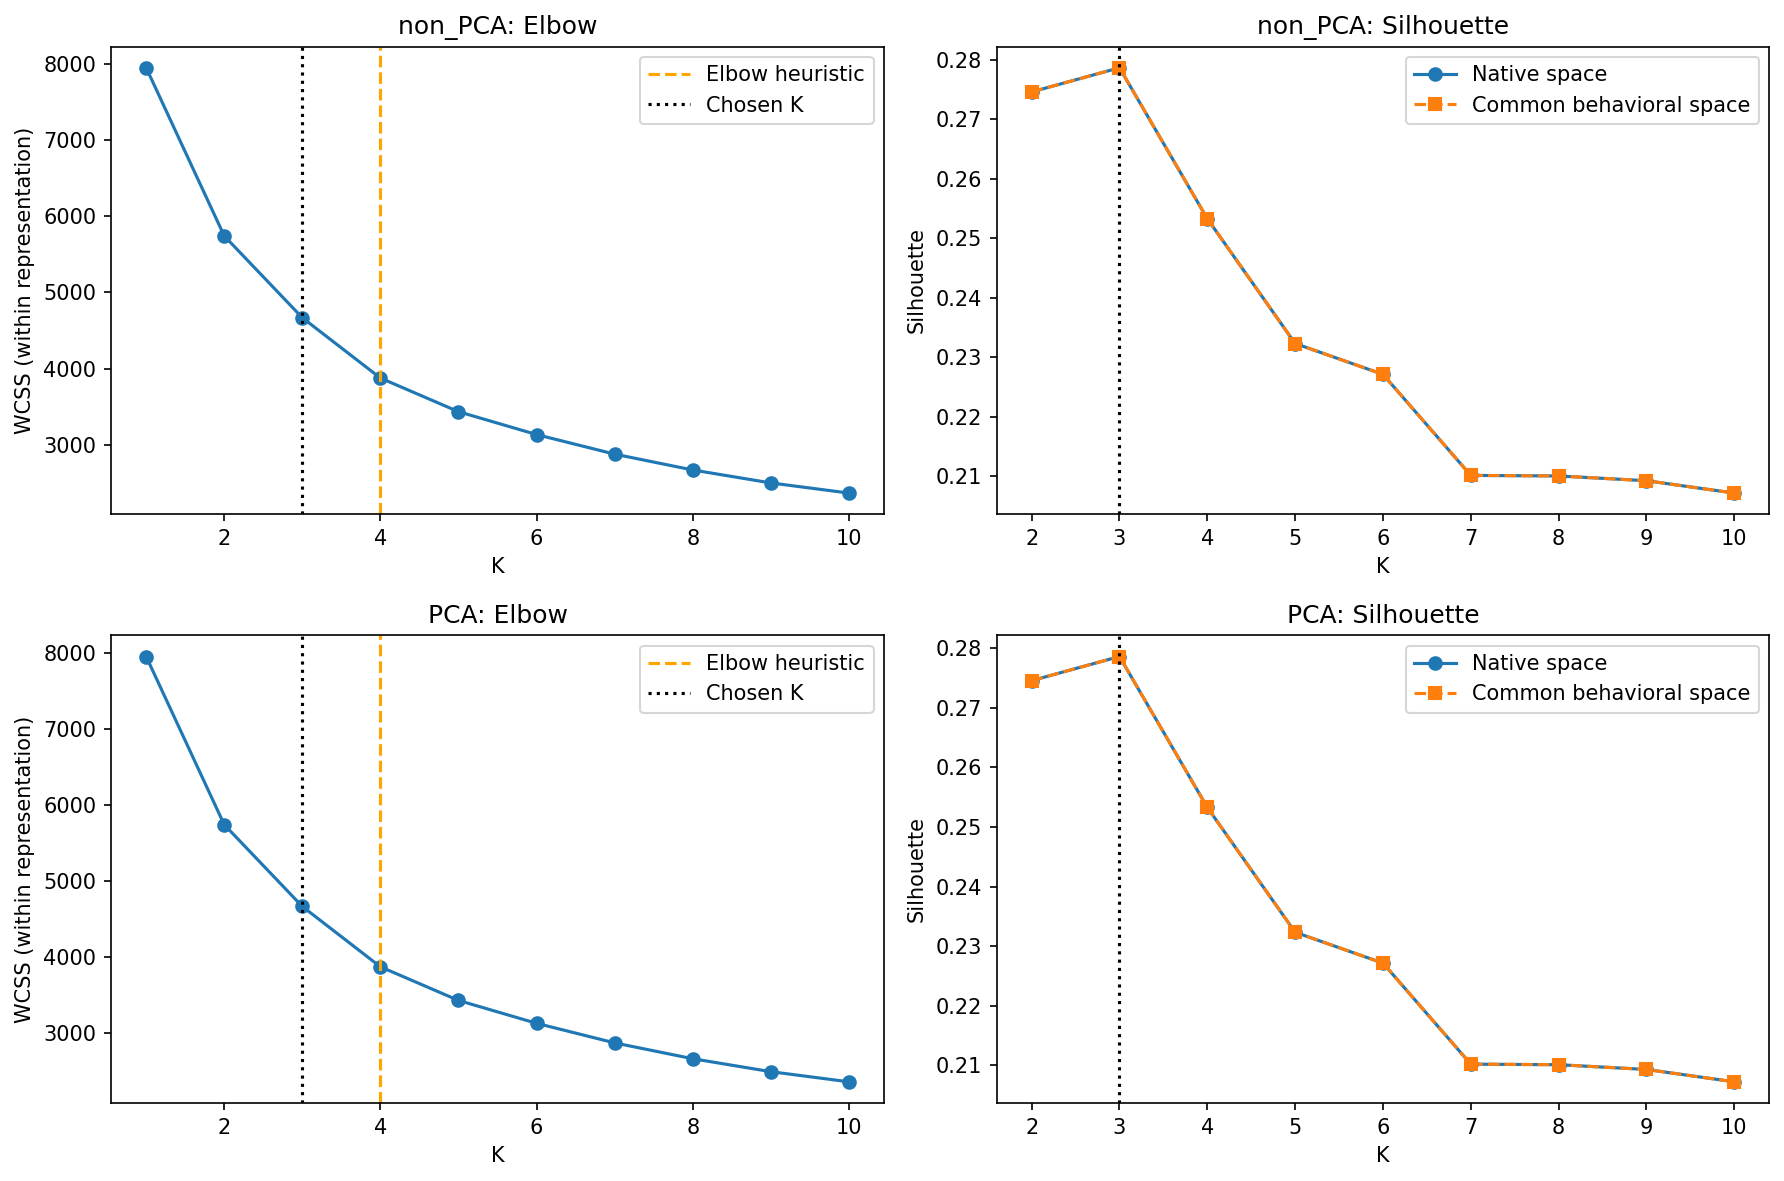

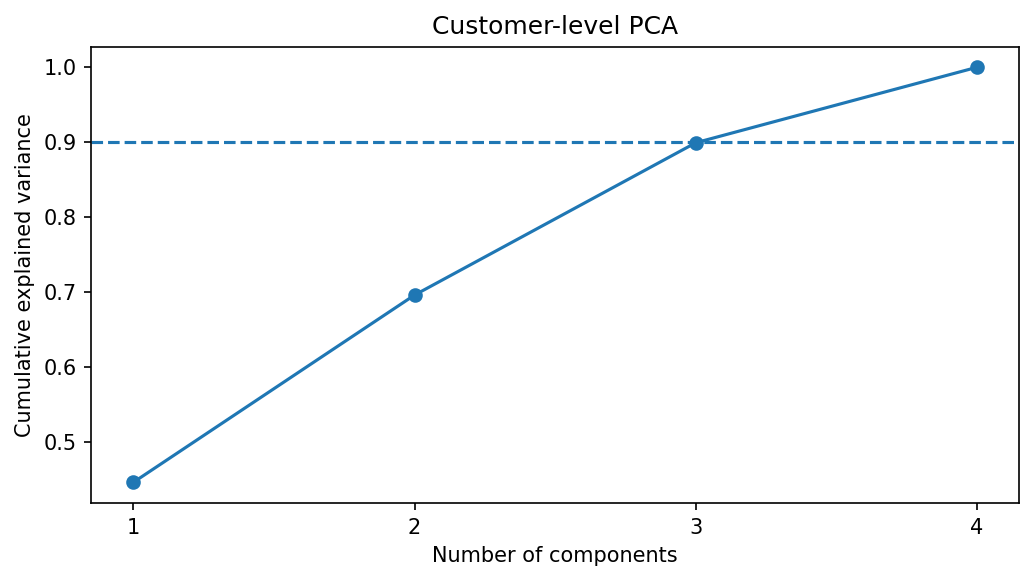

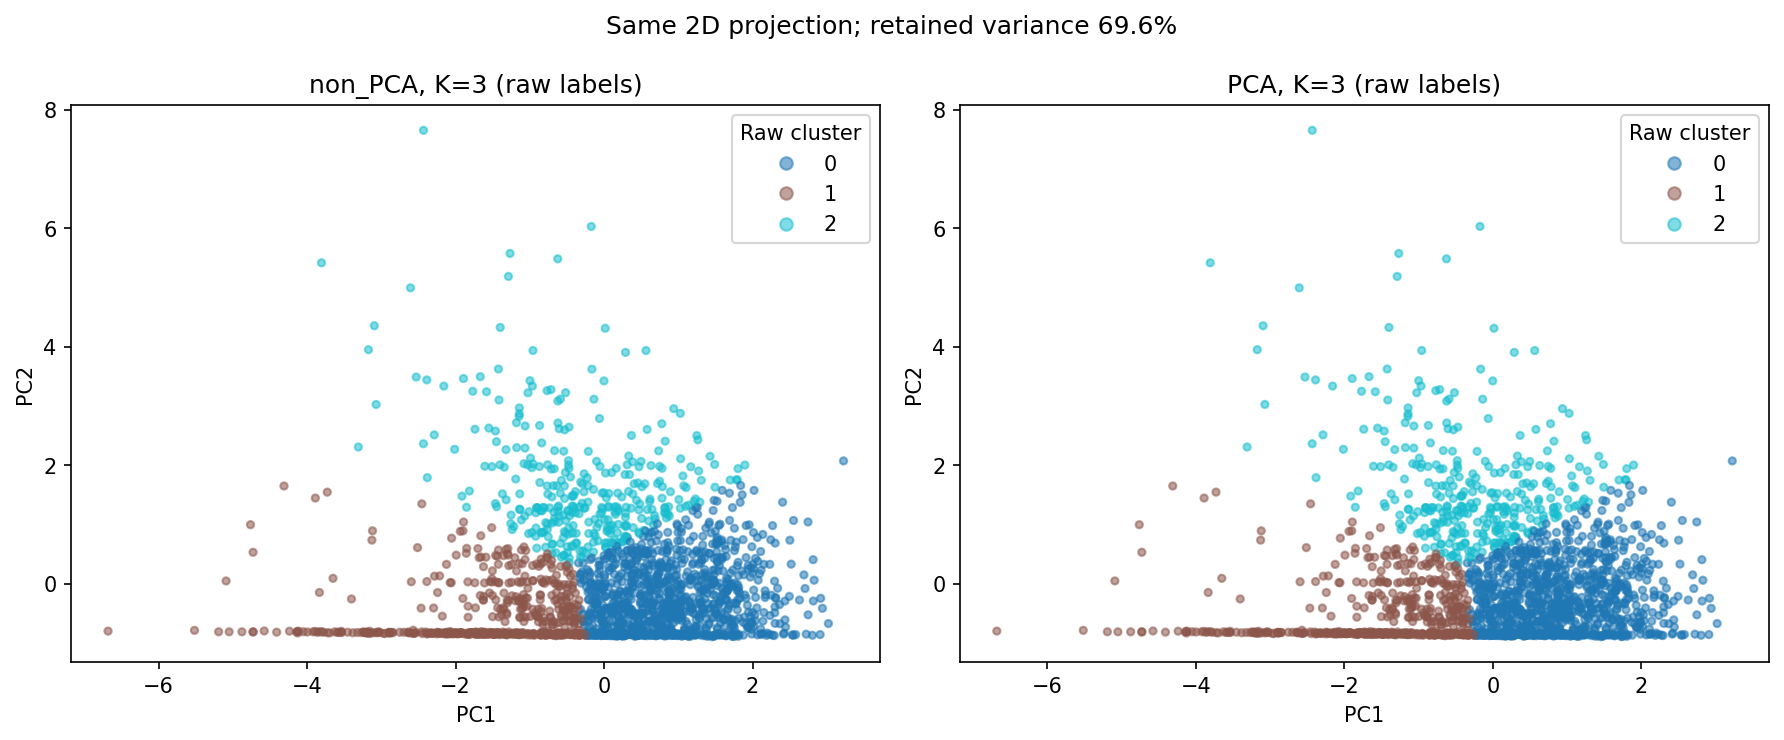

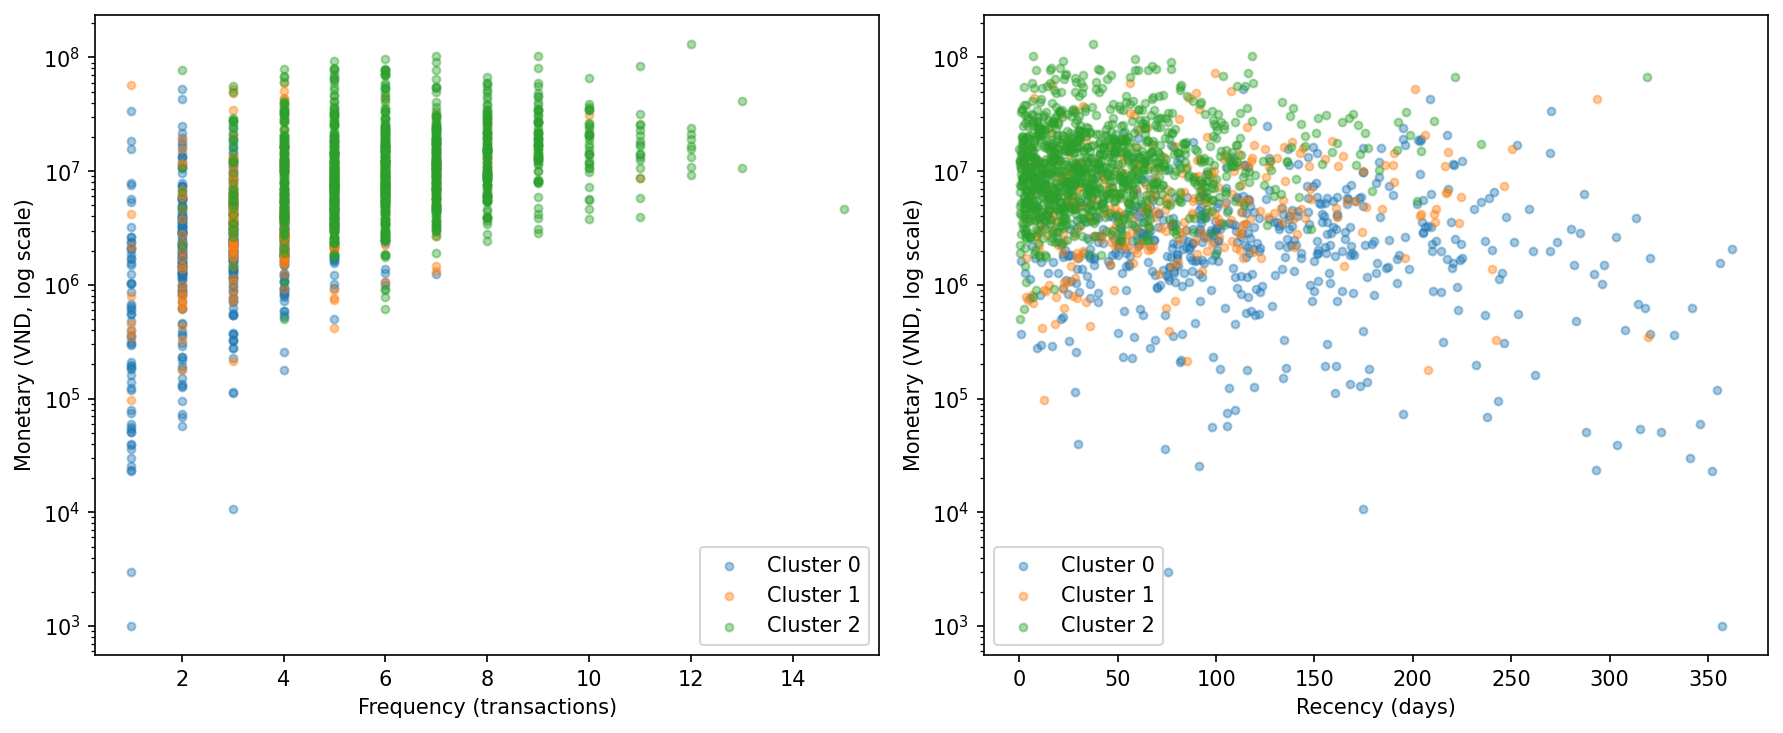

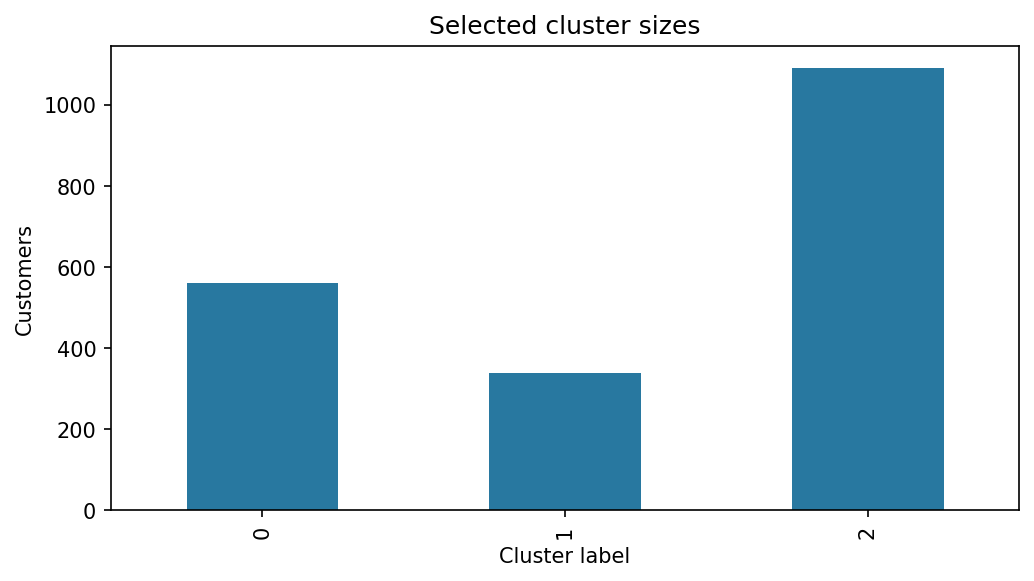

In [7]:
segmented, profiles, label_mapping, cluster_names = make_profiles(customers, best_model.labels_)
profile_view = profiles[['Customers', 'Customer_share', 'Recency_median',
                         'Frequency_median', 'Monetary_median', 'Discount_median']].copy()
profile_view['Customer_share'] = profile_view.Customer_share.map(lambda x: f'{x:.1%}')
profile_view['Discount_median'] = profile_view.Discount_median.map(lambda x: f'{x:.1%}')
profile_view['Monetary_median'] = profile_view.Monetary_median.map(lambda x: f'{x:,.0f}')
profile_view = profile_view.rename(columns={
    'Customers': 'Số khách', 'Customer_share': 'Tỷ trọng',
    'Recency_median': 'Ngày từ lần mua cuối', 'Frequency_median': 'Số giao dịch',
    'Monetary_median': 'Chi tiêu (VND)', 'Discount_median': 'Tỷ lệ giảm'})
profile_view.index.name = 'Cụm'
hien_thi(profile_view.round(1))
hien_thi(Markdown('*Các đặc trưng trong bảng là trung vị theo cụm.*'))
figures = save_figures(metrics, comparison, spaces, pca, segmented, models,
                      profiles, ROOT / 'notebooks/figures/kmeans')
for figure in figures:
    hien_thi(Image(filename=str(figure), width=900))

## 7. Diễn giải và đề xuất có điều kiện
Dữ liệu khách hàng/giao dịch/Rating được sinh ngẫu nhiên: phân cụm thể hiện cấu trúc dataset và cách sinh mẫu. Không biến kết quả mô phỏng thành kết luận thị trường. Đặc trưng Frequency/Monetary có thể tương quan dù đã tránh các cột trùng; nên đọc đồng thời cả hai khi diễn giải.

In [8]:
lines = [f"**Kết quả chọn: {winner}, K={best_k}.**", ""]
for label, row in profiles.iterrows():
    lines.append(f"- **Cụm {label}**: {int(row.Customers)} khách ({row.Customer_share:.1%}); "
                 f"trung vị chi tiêu {row.Monetary_median:,.0f} VND; "
                 f"tần suất {row.Frequency_median:g} giao dịch; "
                 f"lần mua gần nhất cách mốc {row.Recency_median:.1f} ngày; "
                 f"tỷ lệ giảm giá trung vị {row.Discount_median:.1%}.")
chosen = comparison.set_index('space').loc[winner]
lines += ["", f"Silhouette cùng không gian = {chosen.Silhouette_common:.3f}; "
          f"ARI trung bình qua các seed = {chosen.seed_ARI_mean:.3f}.",
          "Silhouette thấp/không cao phải được công bố; việc K-Means luôn chia được cụm không chứng minh phân khúc tự nhiên rõ rệt.",
          "", "**Đề xuất kiểm chứng trên dữ liệu thật:**",
          "1. Nhóm chi tiêu cao: thử chăm sóc sau bán, đo tỷ lệ mua lại và lợi nhuận thay vì mặc định họ trung thành.",
          "2. Nhóm lâu chưa mua: thử chiến dịch tái tương tác có nhóm đối chứng; chưa gọi là rời bỏ khi chưa định nghĩa ngưỡng theo ngành.",
          "3. Nhóm thường mua có giảm giá: thử ưu đãi có kiểm soát và đo lợi nhuận tăng thêm; không suy ra tác động nhân quả từ tỷ lệ giảm quan sát."]
interpretation = '\n'.join(lines)
hien_thi(Markdown(interpretation))

**Kết quả chọn: non_PCA, K=3.**

- **Cụm 0**: 559 khách (28.1%); trung vị chi tiêu 2,370,000 VND; tần suất 3 giao dịch; lần mua gần nhất cách mốc 108.6 ngày; tỷ lệ giảm giá trung vị 0.0%.
- **Cụm 1**: 338 khách (17.0%); trung vị chi tiêu 5,208,140 VND; tần suất 4 giao dịch; lần mua gần nhất cách mốc 65.1 ngày; tỷ lệ giảm giá trung vị 13.1%.
- **Cụm 2**: 1091 khách (54.9%); trung vị chi tiêu 10,570,312 VND; tần suất 6 giao dịch; lần mua gần nhất cách mốc 33.2 ngày; tỷ lệ giảm giá trung vị 2.8%.

Silhouette cùng không gian = 0.279; ARI trung bình qua các seed = 0.999.
Silhouette thấp/không cao phải được công bố; việc K-Means luôn chia được cụm không chứng minh phân khúc tự nhiên rõ rệt.

**Đề xuất kiểm chứng trên dữ liệu thật:**
1. Nhóm chi tiêu cao: thử chăm sóc sau bán, đo tỷ lệ mua lại và lợi nhuận thay vì mặc định họ trung thành.
2. Nhóm lâu chưa mua: thử chiến dịch tái tương tác có nhóm đối chứng; chưa gọi là rời bỏ khi chưa định nghĩa ngưỡng theo ngành.
3. Nhóm thường mua có giảm giá: thử ưu đãi có kiểm soát và đo lợi nhuận tăng thêm; không suy ra tác động nhân quả từ tỷ lệ giảm quan sát.

## 8. Xuất nhãn, model và kiểm tra bàn giao
Ghép `Customer_ID → Cluster_Label` bằng `many_to_one`, giữ nguyên số và thứ tự giao dịch. Xuất file mới trong `data/final`, không ghi đè dữ liệu chung.

Bundle gồm preprocessor, PCA (nếu chọn), K-Means, ánh xạ nhãn và metadata. Khi deploy phải truyền **đặc trưng đã tổng hợp của khách**, không truyền một giao dịch đơn lẻ. Cửa sổ quan sát và định nghĩa Recency phải nhất quán; với dữ liệu tương lai cần chính sách cập nhật snapshot và theo dõi drift. Không gọi `fit` lại khi dự đoán.

In [9]:
bundle, transactions_labeled = export_results(
    ROOT, df, segmented, metrics, comparison, winner, best_k,
    preprocessor, pca, best_model, profiles, label_mapping, cluster_names,
    reference_date, audit, sensitivity)
print('Đã kiểm tra load/predict khớp toàn bộ khách.')
print('Dòng giao dịch trước/sau:', len(df), len(transactions_labeled))
print('Cột nhãn thiếu:', transactions_labeled.Cluster_Label.isna().sum())
print('Dữ liệu đầu vào giữ nguyên SHA-256:', audit['input_sha256'])
hien_thi(segmented[['Customer_ID','Cluster_Label','Cluster_Name']].head())

,Customer_ID,Cluster_Label,Cluster_Name
0,C00001,1,Nhóm 2 — mức chi tiêu trung vị hạng 2/3
1,C00002,0,Nhóm 1 — mức chi tiêu trung vị hạng 1/3
2,C00003,2,Nhóm 3 — mức chi tiêu trung vị hạng 3/3
3,C00004,0,Nhóm 1 — mức chi tiêu trung vị hạng 1/3
4,C00005,0,Nhóm 1 — mức chi tiêu trung vị hạng 1/3


Đã kiểm tra load/predict khớp toàn bộ khách.
Dòng giao dịch trước/sau: 10000 10000
Cột nhãn thiếu: 0
Dữ liệu đầu vào giữ nguyên SHA-256: 054d5ac6972012c4b42c9316a6b7879ca0d0c960e5d28f90324ac2646227fb17


In [10]:
# Ví dụ tích hợp Task 5: dùng các feature một khách đã tổng hợp
import joblib
loaded = joblib.load(ROOT / 'src/models/customer_kmeans_bundle.joblib')
example = customers.iloc[:3].copy()
pred = predict_customers(loaded, example)
hien_thi(example[['Customer_ID'] + NUMERIC].assign(Cluster_Label=pred))

,Customer_ID,Recency,Frequency,Monetary,Mean_Discount_Ratio,Cluster_Label
0,C00001,161.472,4,"3,959,784.000",0.125,1
1,C00002,92.565,2,"4,810,164.000",0.025,0
2,C00003,7.245,6,"53,664,148.000",0.000,2
